# Project Objective
### Employee Attrition Prediction Using Machine Learning

To build a machine learning model that predicts employee attrition and identifies the key factors influencing employees' decisions to leave the company, enabling HR teams to take proactive retention measures.

# Task 1 — Data Loading & Exploration

In [121]:
# Import Required Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import math

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve

import joblib

In [39]:
# Load Dataset
df = pd.read_csv("../Data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [40]:
# Display First 10 Rows
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [41]:
# Check Dataset Shape
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

Rows    : 1470
Columns : 35


The dataset contains employee-related information with multiple features describing demographics, job roles, satisfaction levels, income, performance, and attrition status.

In [42]:
# Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [43]:
# Statistical Summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [44]:
# Identify Target Column
target = "Attrition"

print("Target Column :", target)
print("Unique Values :", df[target].unique())

Target Column : Attrition
Unique Values : <StringArray>
['Yes', 'No']
Length: 2, dtype: str


In [45]:
# Employees Left vs Stayed
attrition_count = df['Attrition'].value_counts()

attrition_count

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [46]:
# Calculate Attrition Rate (%)
attrition_rate = (
    df['Attrition']
    .value_counts(normalize=True)
    * 100
)

attrition_rate

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

In [47]:
left_rate = (df['Attrition'] == 'Yes').mean() * 100

print(f"Employee Attrition Rate: {left_rate:.2f}%")

Employee Attrition Rate: 16.12%


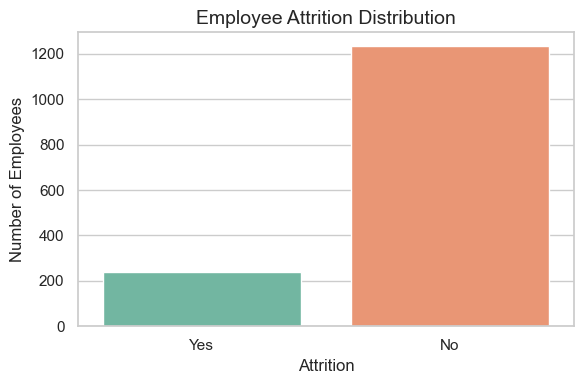

In [48]:
# Visualize Attrition Distribution
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Attrition',
    hue='Attrition',
    palette='Set2',
    legend=False
)

plt.title("Employee Attrition Distribution", fontsize=14)
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.tight_layout()

# Save chart
plt.savefig("..\Charts\employee_attrition_distribution.png", dpi=300, bbox_inches="tight")

plt.show()


In [49]:
# Numeric vs Categorical Columns
numerical_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns

categorical_cols = df.select_dtypes(
    include=['str']
).columns

print("Numerical Columns :", len(numerical_cols))
print("Categorical Columns :", len(categorical_cols))

Numerical Columns : 26
Categorical Columns : 9


In [50]:
print("Numerical Features")
print(list(numerical_cols))

Numerical Features
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [51]:
print("Categorical Features")
print(list(categorical_cols))

Categorical Features
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


In [52]:
# Missing Values Check
missing_values = df.isnull().sum()
missing_values

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [53]:
feature_summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique()
})

feature_summary.head()

,Data Type,Missing Values,Unique Values
Age,int64,0,43
Attrition,str,0,2
BusinessTravel,str,0,3
DailyRate,int64,0,886
Department,str,0,3


# Observation

1. The dataset contains 1470 employee records and 35 features.
2. The target variable is Attrition, indicating whether an employee left the company.
3. The dataset contains both numerical and categorical features.
4. Employees who stayed significantly outnumber employees who left, indicating class imbalance.
5. No major missing value issues were observed in the dataset.
6. Further preprocessing and feature engineering are required before model training.

# Task 3 — Exploratory Data Analysis — EDA

I performed Exploratory Data Analysis (EDA) before preprocessing because it helps in understanding the original dataset, identifying attrition patterns, and discovering meaningful business insights. Working with raw data is more interpretable than analyzing encoded and scaled features.

In [54]:
plt.style.use('ggplot')

sns.set_theme(
    style="whitegrid",
    palette="Set2"
)

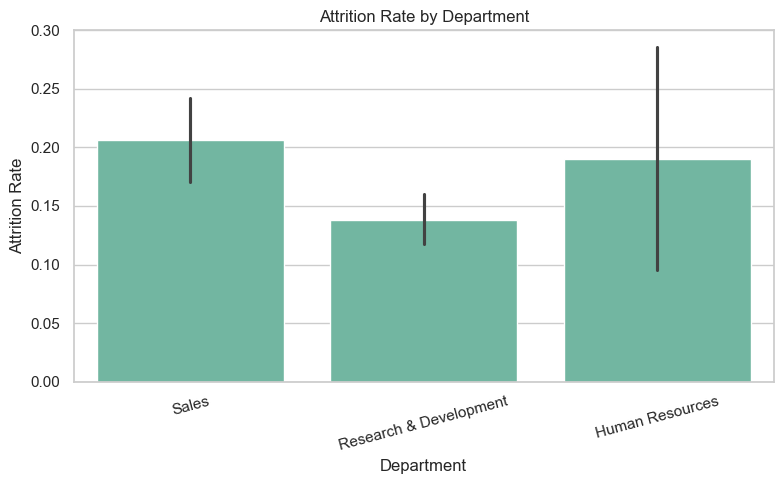

In [55]:
# Attrition Rate by Department
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Department',
    y=(df['Attrition'] == 'Yes').astype(int)
)

plt.title("Attrition Rate by Department")
plt.ylabel("Attrition Rate")
plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "../Charts/attrition_by_department.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Employee attrition is highest in Sales (~20.5%) and lowest in Research & Development (~13.8%), suggesting that retention efforts should primarily focus on the Sales and Human Resources departments.

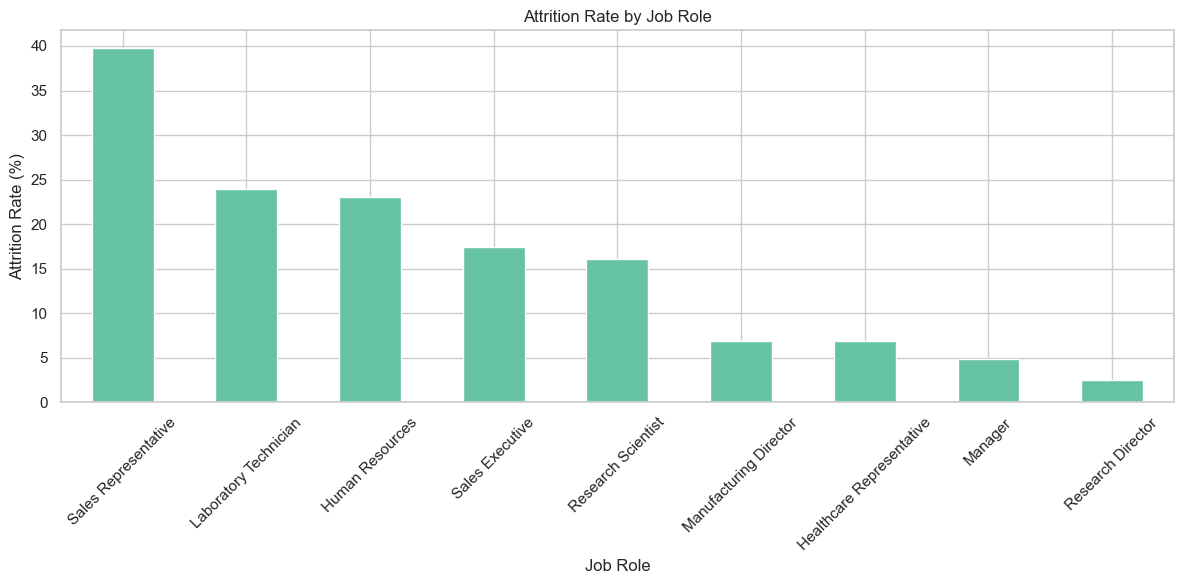

In [56]:
# Attrition Rate by Job Role
role_attrition = pd.crosstab(
    df['JobRole'],
    df['Attrition'],
    normalize='index'
) * 100

plt.figure(figsize=(12,6))

role_attrition['Yes'].sort_values(
    ascending=False
).plot(
    kind='bar'
)

plt.title('Attrition Rate by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Attrition Rate (%)')

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    '../Charts/attrition_by_jobrole.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Sales Representatives experience the highest attrition rate (~40%), while Research Directors (~2.5%) and Managers (~5%) have the lowest attrition rates. This suggests that retention initiatives should primarily target sales and operational roles where employee turnover is most pronounced.

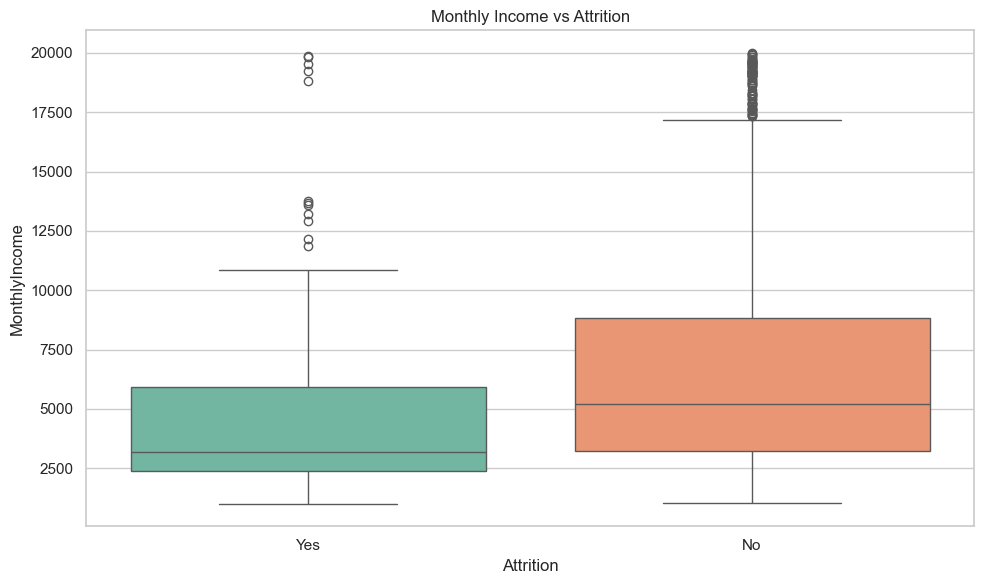

In [57]:
# Attrition vs Monthly Income
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Attrition',
    y='MonthlyIncome',
    hue='Attrition',
    palette='Set2',
    legend=False
)

plt.title('Monthly Income vs Attrition')

plt.tight_layout()

plt.savefig(
    '../Charts/income_vs_attrition.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Employees with lower monthly incomes are more likely to leave the organization, while higher-income employees tend to stay. This suggests that compensation plays a significant role in employee retention and should be investigated further as a key attrition driver.

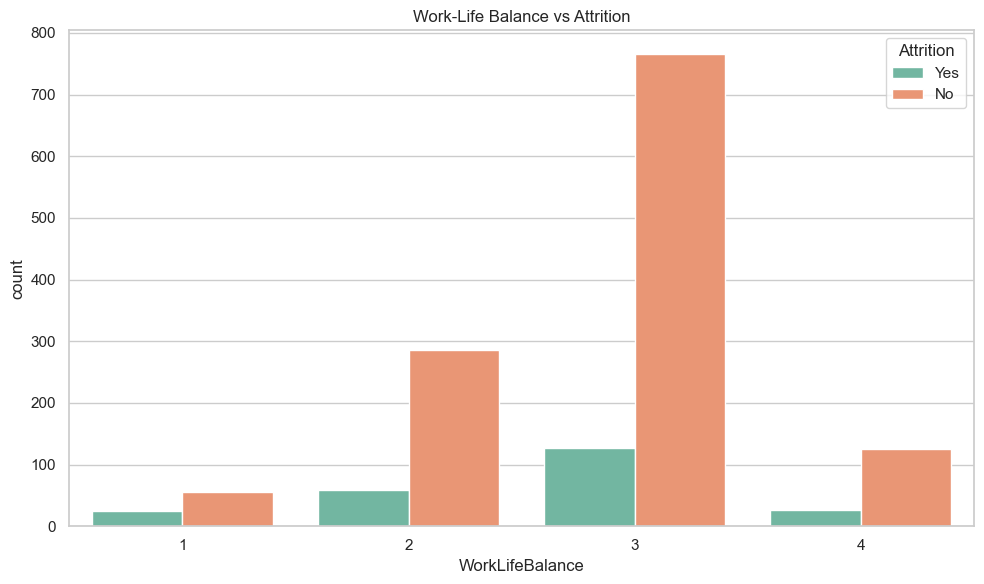

In [58]:
# Attrition vs Work-Life Balance
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='WorkLifeBalance',
    hue='Attrition',
    palette='Set2'
)

plt.title('Work-Life Balance vs Attrition')

plt.tight_layout()

plt.savefig(
    '../Charts/worklife_vs_attrition.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Employees with a Work-Life Balance rating of 3 form the largest group and show the highest number of retained employees. Attrition appears relatively higher among employees with lower Work-Life Balance ratings (1 and 2), suggesting that poor work-life balance may contribute to employee turnover.

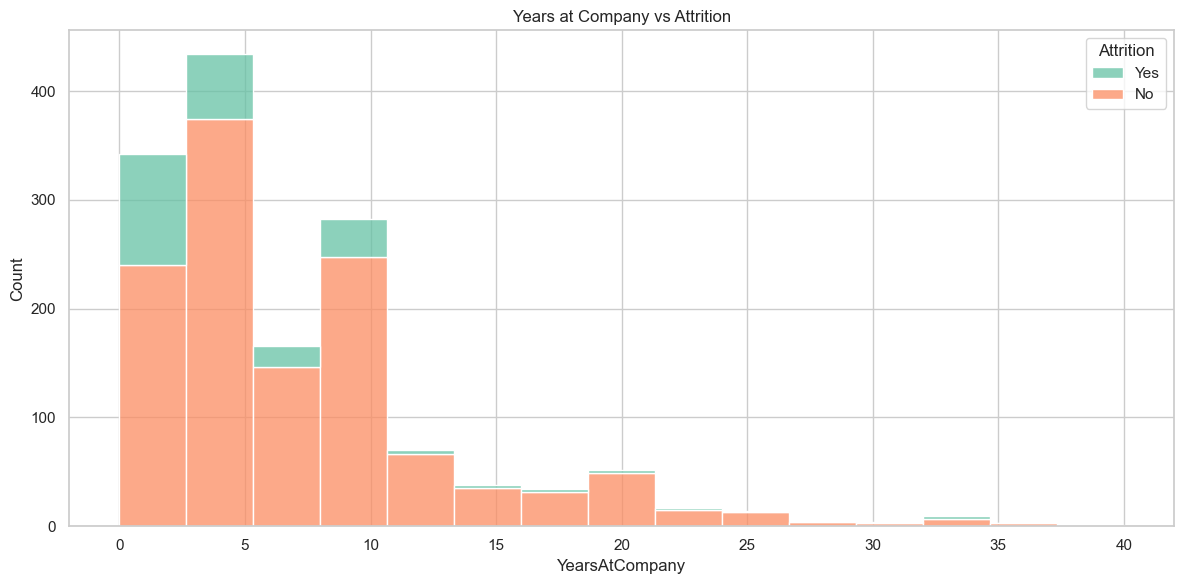

In [59]:
# Attrition vs Years at Company
plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x='YearsAtCompany',
    hue='Attrition',
    multiple='stack',
    bins=15
)

plt.title('Years at Company vs Attrition')

plt.tight_layout()

plt.savefig(
    '../Charts/years_at_company_vs_attrition.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Most employee attrition occurs within the first 0–5 years of employment, indicating that early-career employees are more likely to leave the organization. Employees with longer tenure (10+ years) show significantly lower attrition, suggesting stronger retention among experienced staff.

<Axes: xlabel='Gender', ylabel='count'>

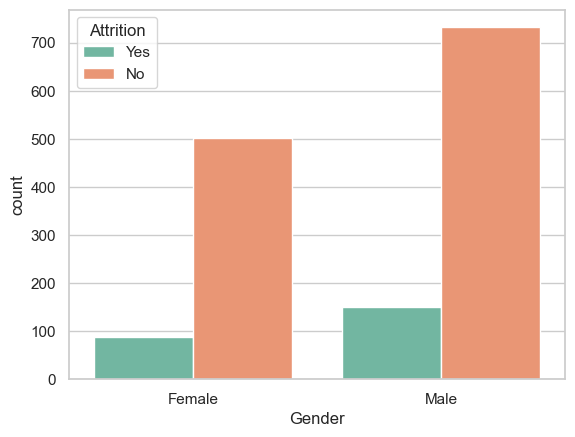

In [60]:
sns.countplot(data=df, x='Gender', hue='Attrition')

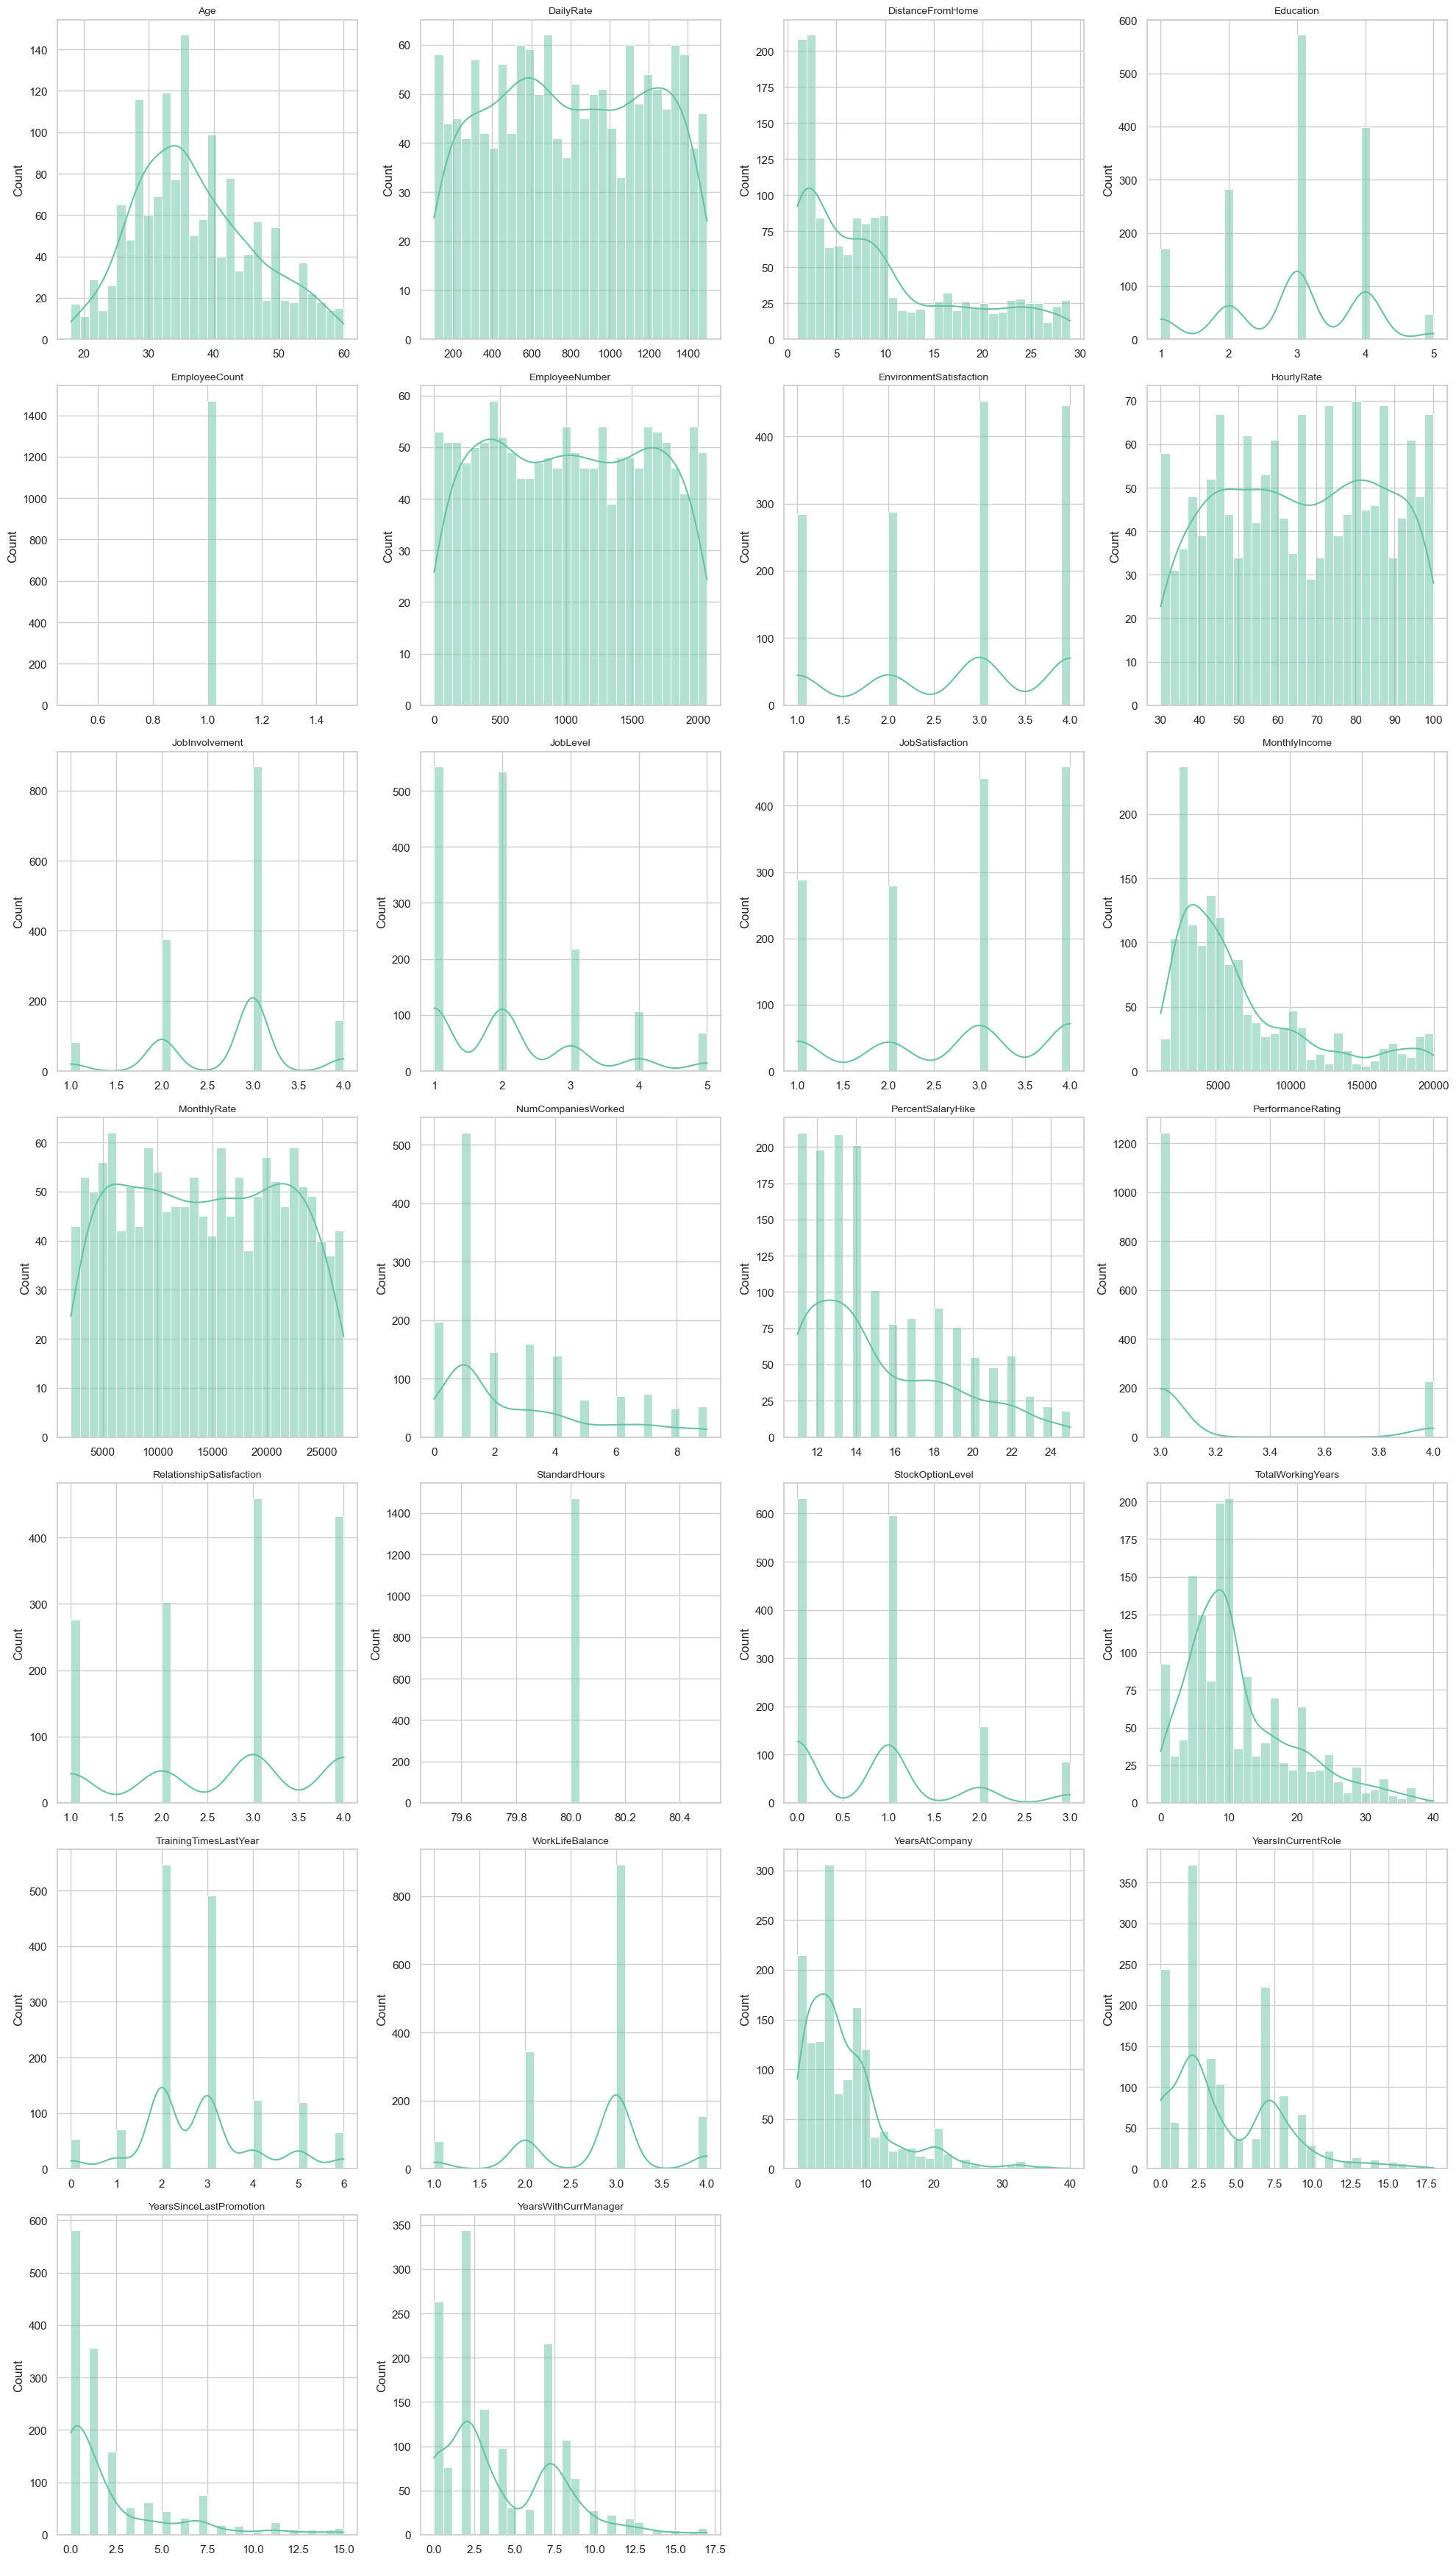

In [61]:
#Disstribution Plots For Numerical Columns

# Grid size
n_cols = 4
n_rows = math.ceil(len(numerical_cols) / n_cols)

plt.figure(figsize=(20, 5 * n_rows))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(n_rows, n_cols, i)

    sns.histplot(
        df[col],
        kde=True,
        bins=30
    )

    plt.title(col, fontsize=10)
    plt.xlabel("")
    plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    "../Charts/Numerical_Features_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

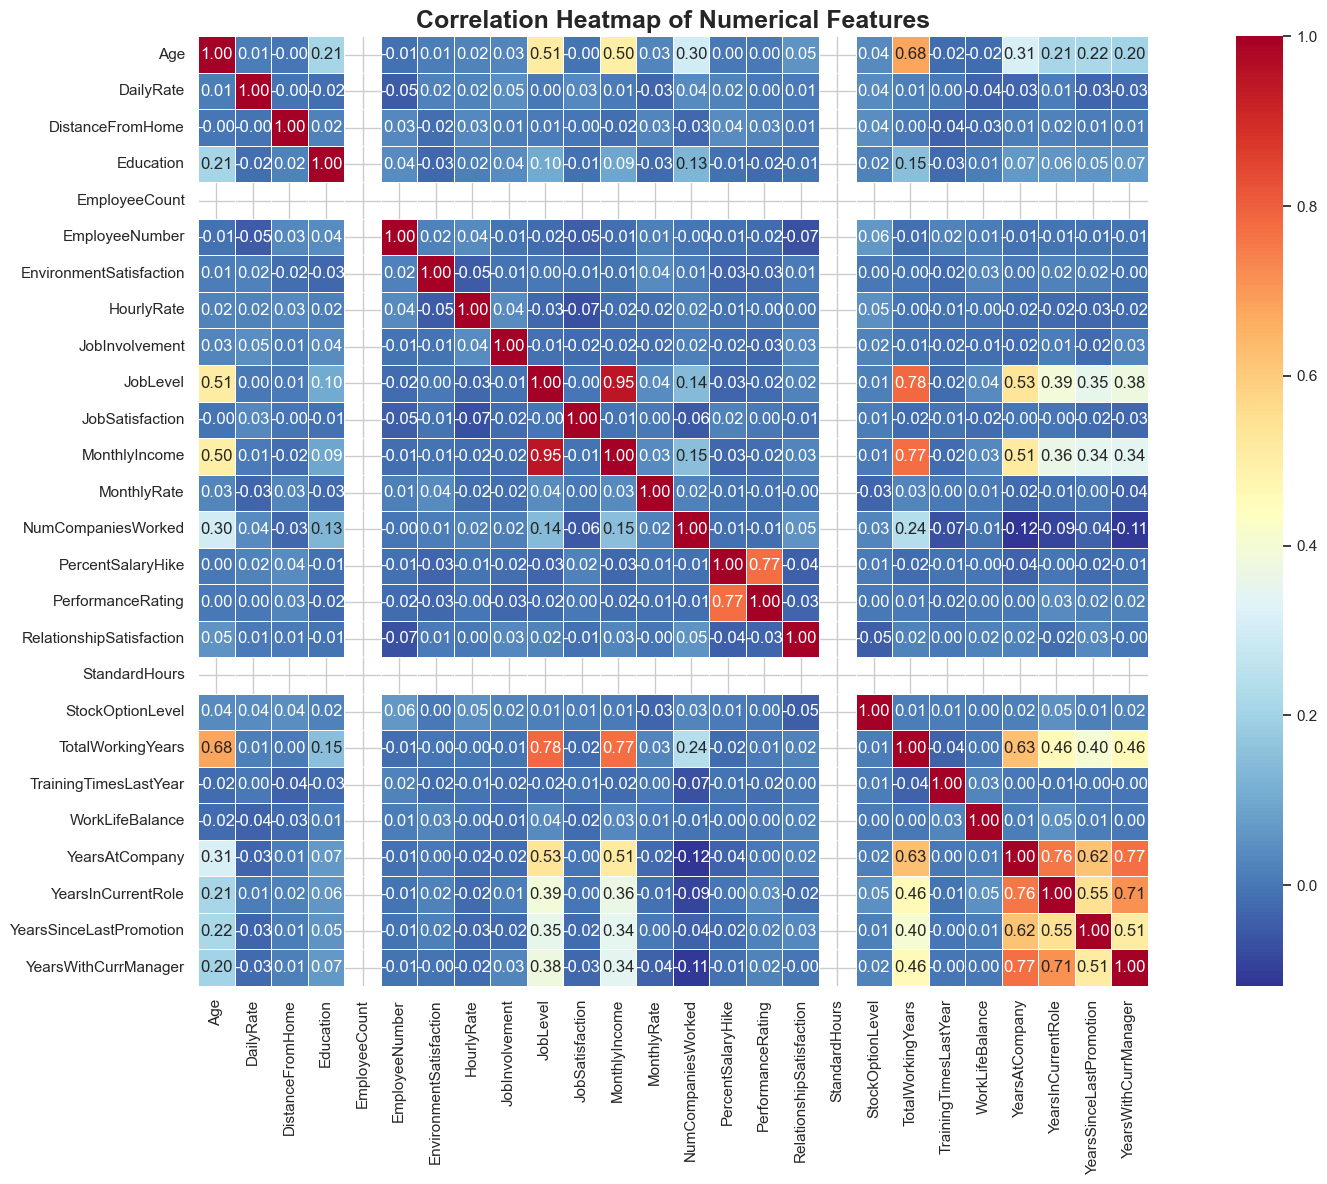

In [62]:
# Correlation Heatmap
plt.figure(figsize=(18,12))

corr_matrix = df.select_dtypes(
    include=['int64', 'float64']
).corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    linewidths=0.5,
    square=True
)

plt.title(
    'Correlation Heatmap of Numerical Features',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    '../Charts/correlation_heatmap.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

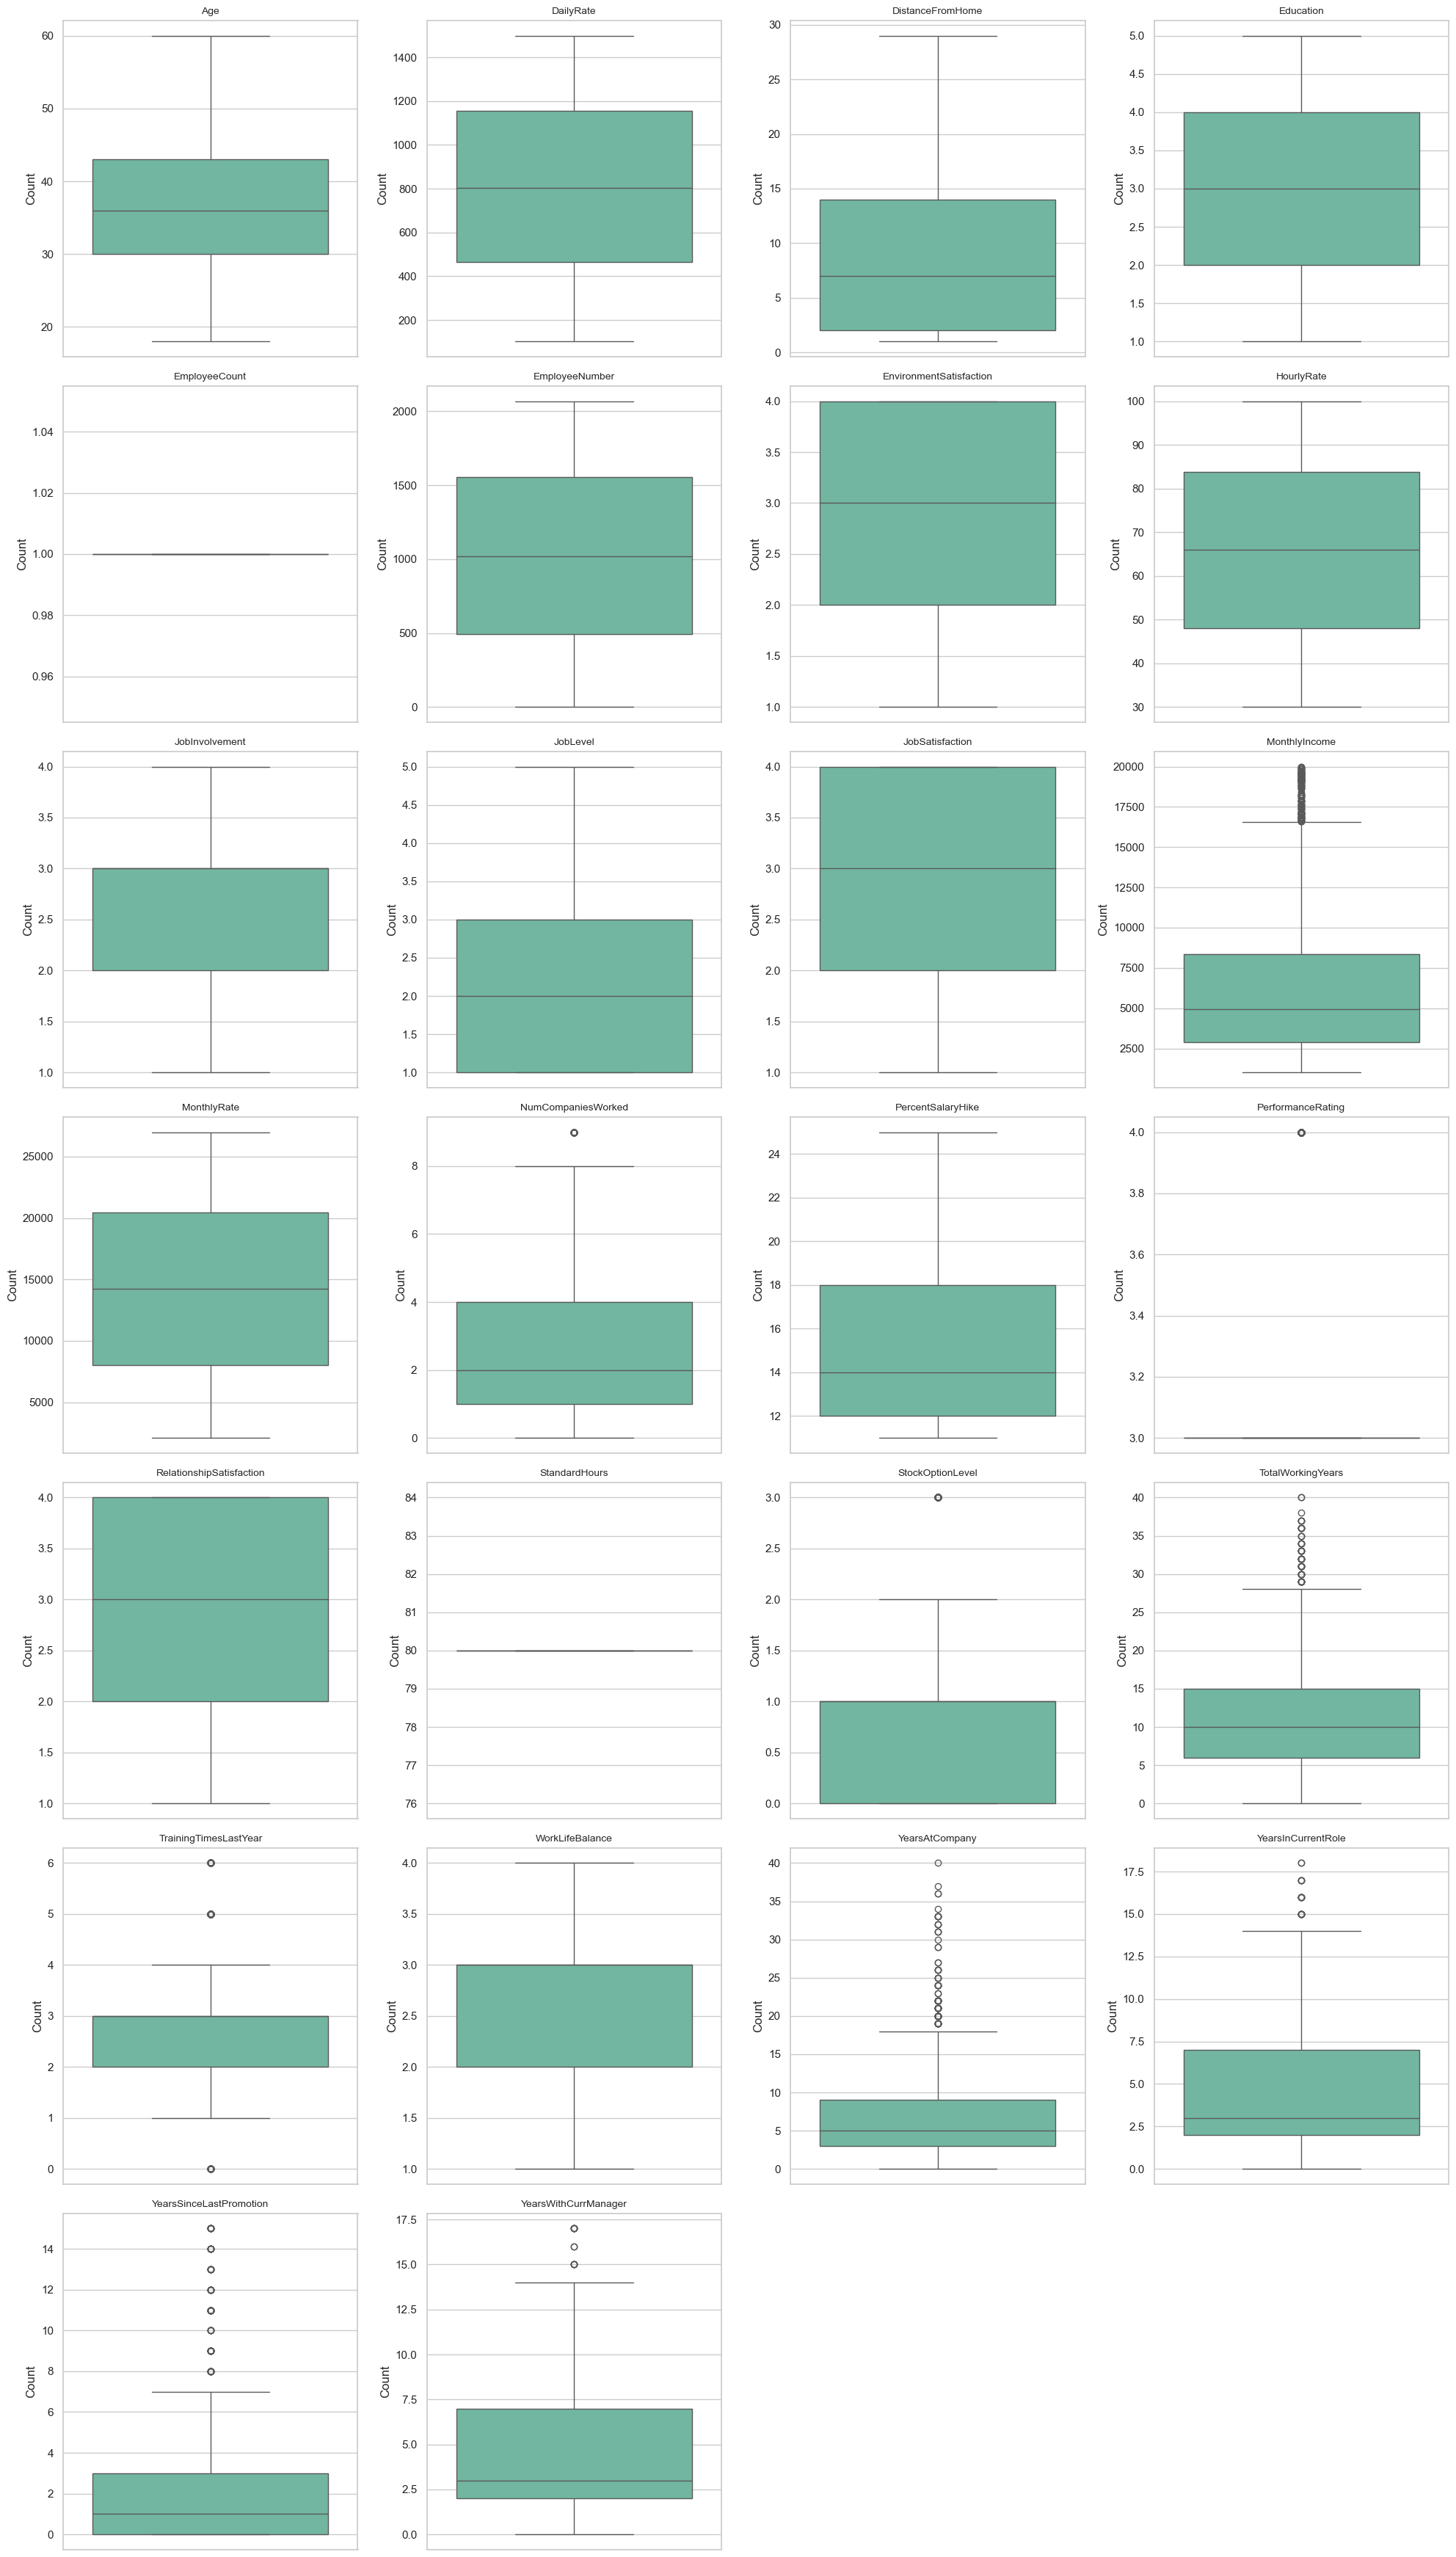

In [63]:
plt.figure(figsize=(20, 5 * n_rows))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(n_rows, n_cols, i)

    sns.boxplot(
        df[col]
    )

    plt.title(col, fontsize=10)
    plt.xlabel("")
    plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    "../Charts/Numerical_Features_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [64]:
outlier_counts = {}

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outlier_counts[col] = len(outliers)

outlier_df = (
    pd.DataFrame(
        outlier_counts.items(),
        columns=['Feature', 'Outlier_Count']
    )
    .sort_values(
        by='Outlier_Count',
        ascending=False
    )
)


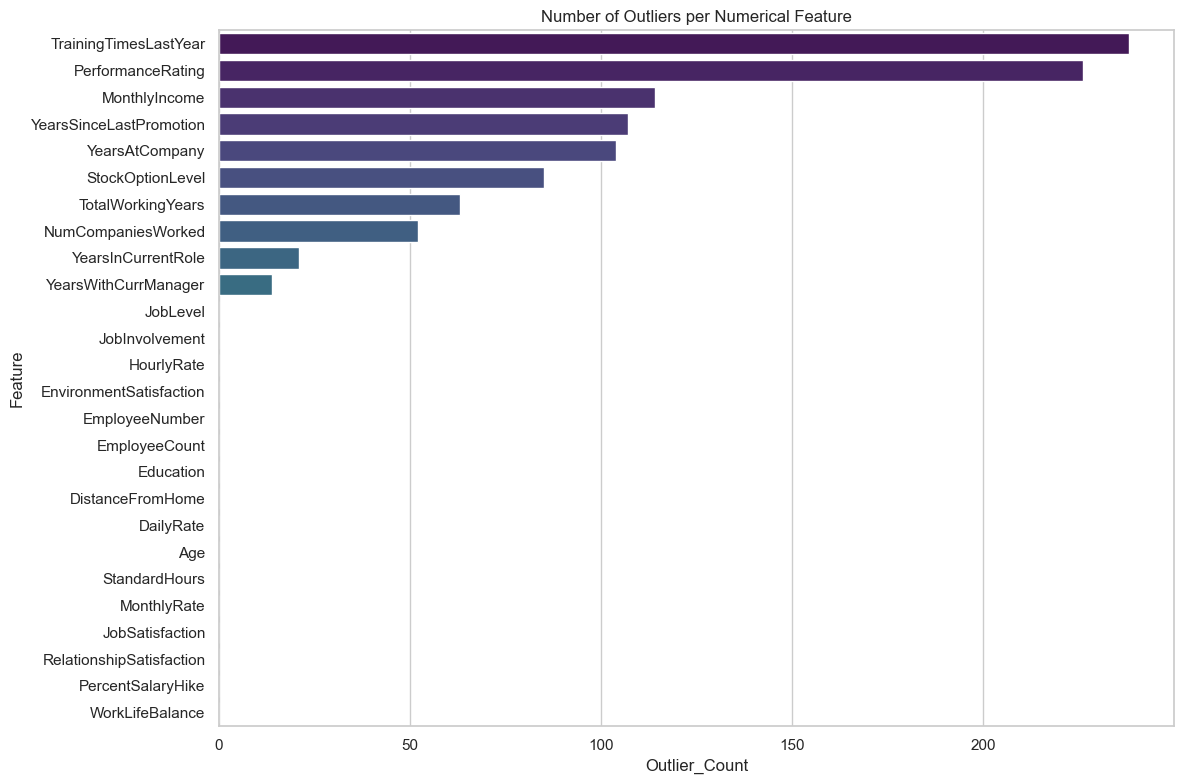

In [65]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=outlier_df,
    x='Outlier_Count',
    y='Feature',
    palette='viridis',
    hue='Feature',
    legend=False
)

plt.title("Number of Outliers per Numerical Feature")

plt.tight_layout()

plt.savefig(
    "../Charts/Outlier_Counts.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

From the outlier analysis, I observed that features such as TrainingTimesLastYear, PerformanceRating, MonthlyIncome, and YearsAtCompany contain a higher number of outliers compared to other variables. These outliers may represent employees with exceptional performance, higher salaries, or longer tenure and could provide valuable insights rather than being treated as errors.

# Task 2 — Data Cleaning & Preprocessing

### Objective

To prepare the employee dataset for machine learning by handling missing values, removing irrelevant features, encoding categorical variables, and scaling numerical features.

In [66]:
# Check Missing Values
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [67]:
# Check Duplicate Records
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [68]:
# Drop Irrelevant Columns
columns_to_drop = [
    'EmployeeNumber',
    'EmployeeCount',
    'Over18',
    'StandardHours'
]

df = df.drop(columns=columns_to_drop)

In [69]:
print(df.shape)

(1470, 31)


In [70]:
# Convert Target Variable
df['Attrition'] = df['Attrition'].map({
    'No':0,
    'Yes':1
})

df['Attrition'].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [71]:
# Convert Target Variable
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [76]:
numerical_cols = X.select_dtypes(
    include=['int64','float64']
).columns.tolist()

categorical_cols = X.select_dtypes(
    include=['str']
).columns.tolist()

In [77]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_cols
        ),
        (
            'cat',
            OneHotEncoder(
            handle_unknown='ignore',
            drop='first'
            ),
            categorical_cols
        )
    ]
)

# Task 4 — Model Building & Comparison

## Objective

To train and compare multiple machine learning classification models for predicting employee attrition and identify the model that provides the best predictive performance.

In [81]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1176, 30)
(294, 30)


In [89]:
# Logistic Regression
log_reg = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)
# Logistic Regression Pipeline
log_reg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', log_reg)
])

log_reg_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [90]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

# Random Forest Pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', rf)
])


rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [91]:
# Gradient Boosting
gb = GradientBoostingClassifier(
    random_state=42,
)

# Gradient Boosting Pipeline
gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', gb)
])

gb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [124]:
# Save All Three Models

# Logistic Regression
joblib.dump(
    log_reg_pipeline,
    "../Models/logistic_regression.pkl"
)

# Random Forest
joblib.dump(
    rf_pipeline,
    "../Models/random_forest.pkl"
)

# Gradient Boosting
joblib.dump(
    gb_pipeline,
    "../Models/gradient_boosting.pkl"
)

print("All models saved successfully!")

All models saved successfully!


In [92]:
# Predictions
y_pred_lr = log_reg_pipeline.predict(X_test)

y_pred_rf = rf_pipeline.predict(X_test)

y_pred_gb = gb_pipeline.predict(X_test)

In [93]:
# Prediction Probabilities
y_prob_lr = log_reg_pipeline.predict_proba(X_test)[:,1]

y_prob_rf = rf_pipeline.predict_proba(X_test)[:,1]

y_prob_gb = gb_pipeline.predict_proba(X_test)[:,1]

In [94]:
all_predictions = pd.DataFrame({
    'Actual': y_test.map({0:'No', 1:'Yes'}),

    'Logistic_Prediction': pd.Series(
        y_pred_lr,
        index=y_test.index
    ).map({0:'No', 1:'Yes'}),

    'RandomForest_Prediction': pd.Series(
        y_pred_rf,
        index=y_test.index
    ).map({0:'No', 1:'Yes'}),

    'GradientBoosting_Prediction': pd.Series(
        y_pred_gb,
        index=y_test.index
    ).map({0:'No', 1:'Yes'}),

    'LR_Probability': y_prob_lr,
    'RF_Probability': y_prob_rf,
    'GB_Probability': y_prob_gb
})

all_predictions.head(20)

,Actual,Logistic_Prediction,RandomForest_Prediction,GradientBoosting_Prediction,LR_Probability,RF_Probability,GB_Probability
1061,No,No,Yes,No,0.322964,0.615,0.489297
891,No,No,No,No,0.022063,0.030,0.018513
456,No,No,No,No,0.444296,0.085,0.130713
922,No,No,No,No,0.035724,0.010,0.009098
69,Yes,Yes,No,No,0.665732,0.230,0.288199
1164,No,Yes,No,No,0.623190,0.100,0.102163
406,No,No,No,No,0.079678,0.030,0.073203
1330,No,No,No,No,0.133203,0.075,0.056434
1232,No,No,No,No,0.021108,0.010,0.012156
1311,No,No,No,No,0.263984,0.410,0.461217


# Task 5 — Model Evaluation

In [97]:
evaluation_df = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting'
    ],

    'Precision':[
        precision_score(y_test,y_pred_lr),
        precision_score(y_test,y_pred_rf),
        precision_score(y_test,y_pred_gb)
    ],

    'Recall':[
        recall_score(y_test,y_pred_lr),
        recall_score(y_test,y_pred_rf),
        recall_score(y_test,y_pred_gb)
    ],

    'F1 Score':[
        f1_score(y_test,y_pred_lr),
        f1_score(y_test,y_pred_rf),
        f1_score(y_test,y_pred_gb)
    ],

    'ROC-AUC':[
        roc_auc_score(y_test,y_prob_lr),
        roc_auc_score(y_test,y_prob_rf),
        roc_auc_score(y_test,y_prob_gb)
    ]
})

evaluation_df.round(4)

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.3563,0.6596,0.4627,0.8035
1,Random Forest,0.5000,0.0851,0.1455,0.7689
2,Gradient Boosting,0.5882,0.2128,0.3125,0.7941


In [99]:
# Confusion Matrix Logistic Regression
cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

cm_lr

array([[191,  56],
       [ 16,  31]])

In [100]:
# Confusion Matrix Random Forest
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

cm_rf

array([[243,   4],
       [ 43,   4]])

In [101]:
# Confusion Matrix
cm_gb = confusion_matrix(
    y_test,
    y_pred_gb
)

cm_gb

array([[240,   7],
       [ 37,  10]])

Among the three models, Logistic Regression achieved the best overall performance with the highest ROC-AUC score (0.8035) and F1-Score (0.4627). The model also demonstrated the highest recall, successfully identifying a larger proportion of employees likely to leave the company. Therefore, Logistic Regression was selected as the best-performing model for employee attrition prediction.

Since the dataset is imbalanced and the main objective is to identify employees who are likely to leave, a higher recall is especially important. Logistic Regression was able to correctly identify a larger proportion of employees at risk of attrition, while Random Forest and Gradient Boosting missed many actual attrition cases.

In [103]:
# Get Feature Names from ColumnTransformer
feature_names = preprocessor.get_feature_names_out()

feature_names[:10]

array(['num__Age', 'num__DailyRate', 'num__DistanceFromHome',
       'num__Education', 'num__EnvironmentSatisfaction',
       'num__HourlyRate', 'num__JobInvolvement', 'num__JobLevel',
       'num__JobSatisfaction', 'num__MonthlyIncome'], dtype=object)

In [106]:
coefficients = log_reg_pipeline.named_steps[
    'model'
].coef_[0]

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Importance': np.abs(coefficients)
})


In [107]:
# Top 10 Most Important Features
top_10_features = (
    feature_importance
    .sort_values(
        by='Importance',
        ascending=False
    )
    .head(10)
)

top_10_features = top_10_features.reset_index(drop=True)

top_10_features.insert(
    0,
    'Rank',
    range(1, len(top_10_features)+1)
)

top_10_features

,Rank,Feature,Coefficient,Importance
0,1,cat__OverTime_Yes,1.623568,1.623568
1,2,cat__BusinessTravel_Travel_Frequently,1.598904,1.598904
2,3,cat__JobRole_Laboratory Technician,1.569722,1.569722
3,4,cat__JobRole_Sales Representative,1.276684,1.276684
4,5,cat__JobRole_Research Director,-1.117217,1.117217
5,6,cat__EducationField_Other,-1.027636,1.027636
6,7,cat__BusinessTravel_Travel_Rarely,0.906933,0.906933
7,8,cat__MaritalStatus_Single,0.864752,0.864752
8,9,cat__JobRole_Human Resources,0.645775,0.645775
9,10,num__TotalWorkingYears,-0.615535,0.615535


# Task 6 — Visualization

## Chart 1: Attrition Rate by Department and Job Role

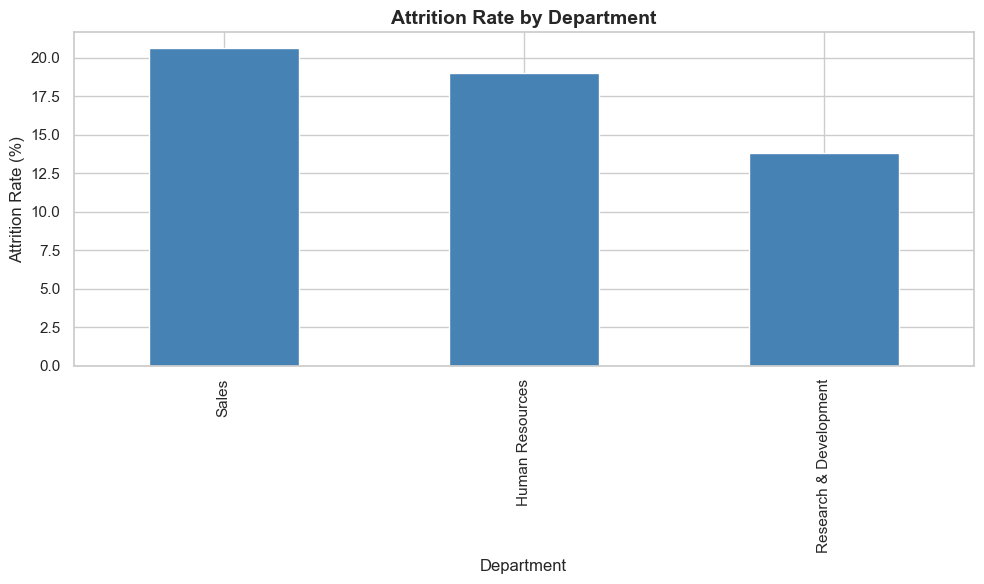

In [109]:
# Attrition Rate by Department
dept_attrition = (
    pd.crosstab(
        df['Department'],
        df['Attrition'],
        normalize='index'
    ) * 100
)

plt.figure(figsize=(10,6))

dept_attrition[1].sort_values(
    ascending=False
).plot(
    kind='bar',
    color='steelblue'
)

plt.title(
    'Attrition Rate by Department',
    fontsize=14,
    fontweight='bold'
)

plt.ylabel('Attrition Rate (%)')
plt.xlabel('Department')

plt.tight_layout()

plt.savefig(
    '../Charts/attrition_by_department.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

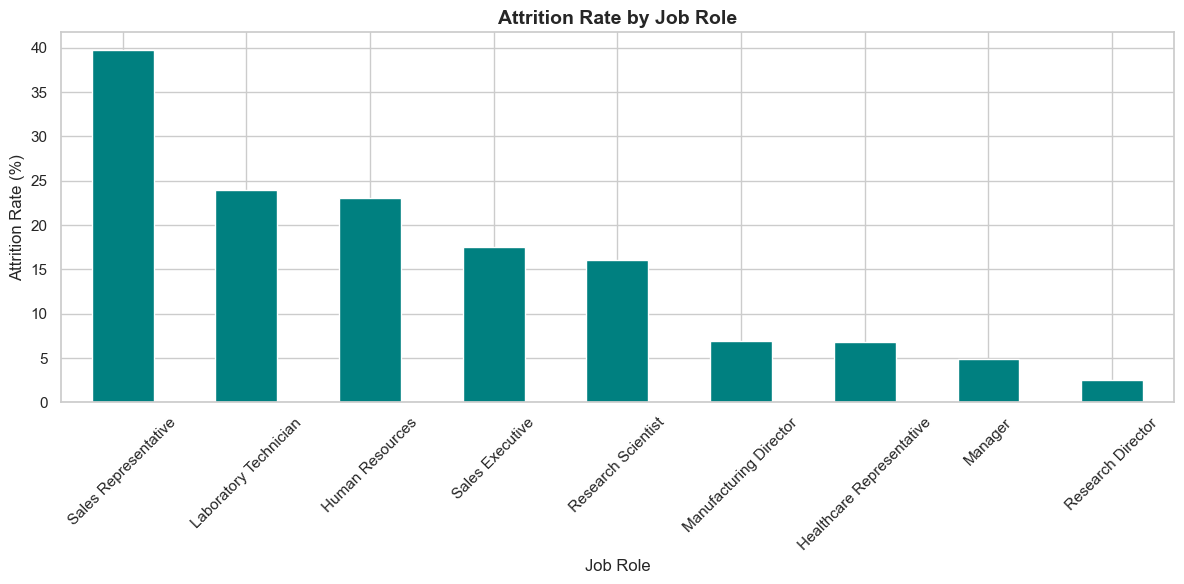

In [111]:
# Attrition Rate by Job Role
jobrole_attrition = (
    pd.crosstab(
        df['JobRole'],
        df['Attrition'],
        normalize='index'
    ) * 100
)

plt.figure(figsize=(12,6))

jobrole_attrition[1].sort_values(
    ascending=False
).plot(
    kind='bar',
    color='teal'
)

plt.title(
    'Attrition Rate by Job Role',
    fontsize=14,
    fontweight='bold'
)

plt.ylabel('Attrition Rate (%)')
plt.xlabel('Job Role')

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    '../Charts/attrition_by_jobrole.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Chart 2: Monthly Income vs Attrition

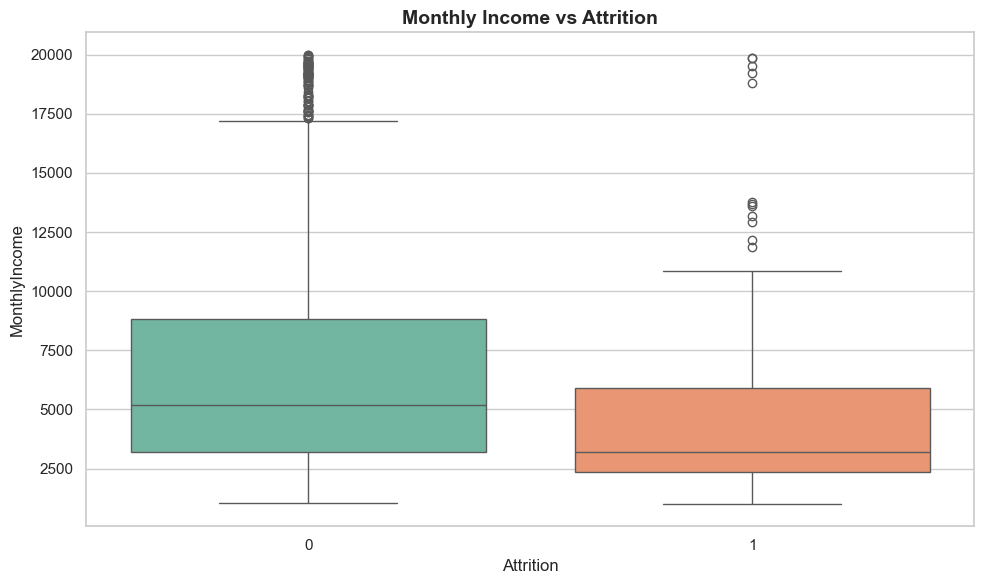

In [115]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Attrition',
    y='MonthlyIncome',
    hue='Attrition',
    palette='Set2',
    legend=False
)

plt.title(
    'Monthly Income vs Attrition',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    '../Charts/income_vs_attrition.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Chart 3: Confusion Matrix (Best Model)

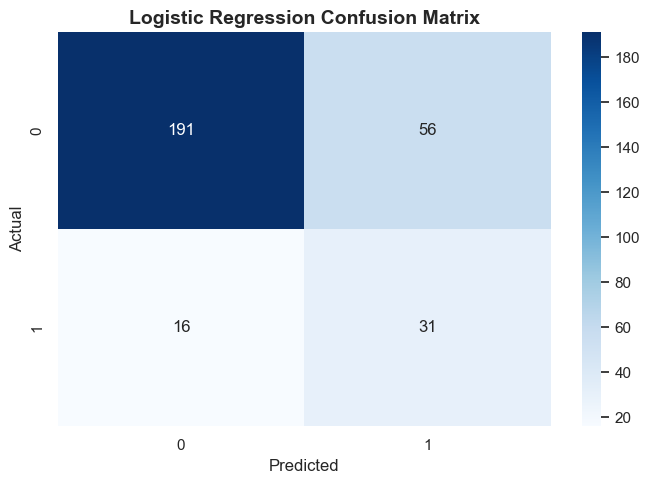

In [116]:

plt.figure(figsize=(7,5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    'Logistic Regression Confusion Matrix',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()

plt.savefig(
    '../Charts/confusion_matrix.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Chart 4: Top 10 Feature Importance

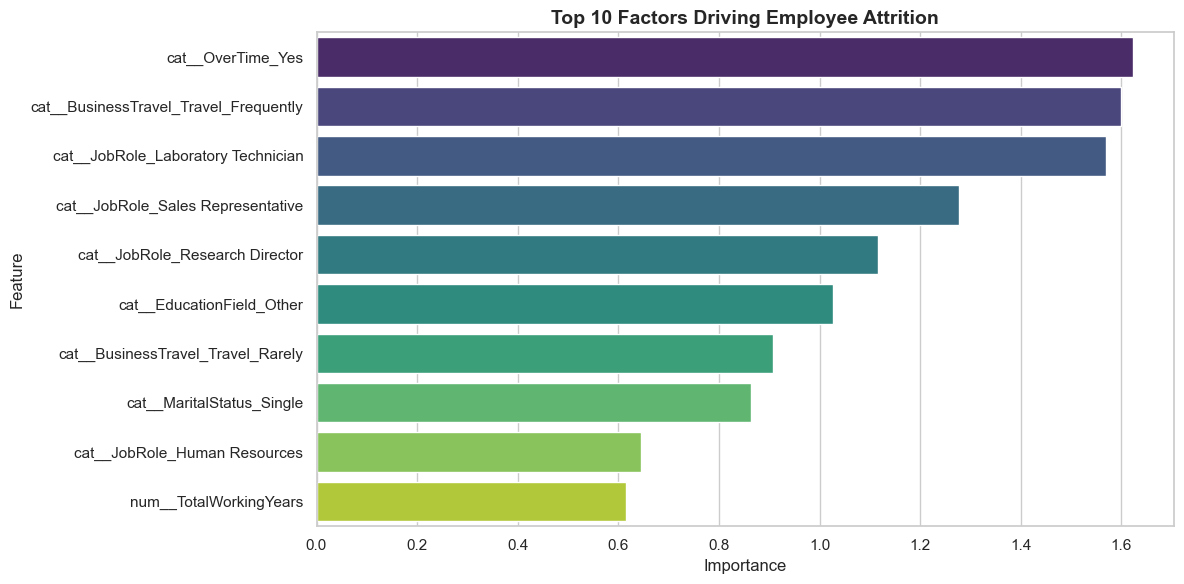

In [118]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_10_features,
    x='Importance',
    y='Feature',
    palette='viridis',
    hue='Feature',
    legend=False
)

plt.title(
    'Top 10 Factors Driving Employee Attrition',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()

plt.savefig(
    '../Charts/feature_importance.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Chart 5 : ROC Curve Comparison

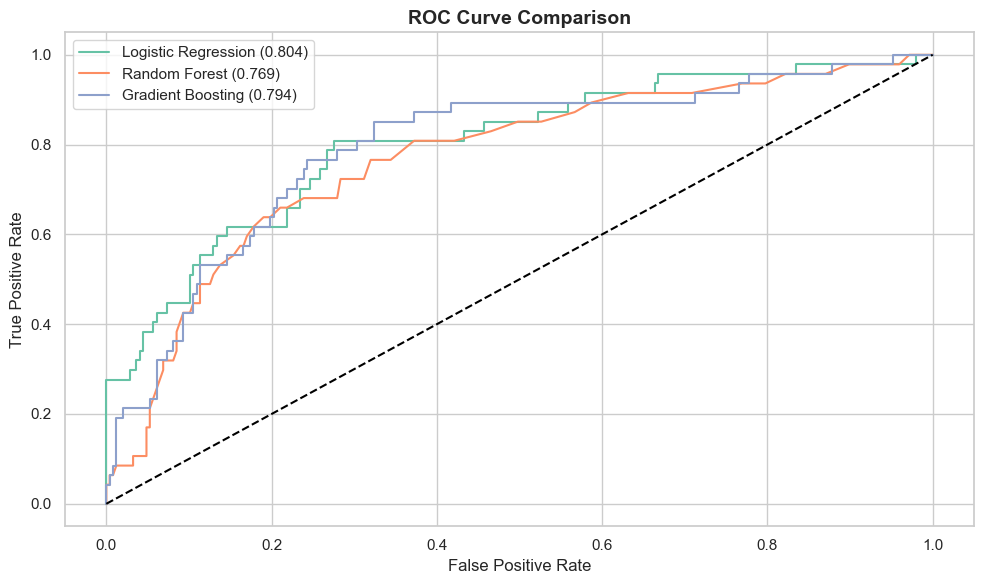

In [120]:
fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_prob_lr
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

fpr_gb, tpr_gb, _ = roc_curve(
    y_test,
    y_prob_gb
)

plt.figure(figsize=(10,6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f'Logistic Regression ({roc_auc_score(y_test,y_prob_lr):.3f})'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest ({roc_auc_score(y_test,y_prob_rf):.3f})'
)

plt.plot(
    fpr_gb,
    tpr_gb,
    label=f'Gradient Boosting ({roc_auc_score(y_test,y_prob_gb):.3f})'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='black'
)

plt.title(
    'ROC Curve Comparison',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend()

plt.tight_layout()

plt.savefig(
    '../Charts/roc_curve_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Task 7 — HR Insights & Business Recommendations

The analysis identified Job Role, Monthly Income, and Overtime as the strongest factors influencing employee attrition. 

Sales Representatives, Laboratory Technicians, and Human Resources employees showed the highest attrition rates and should be prioritized for retention efforts. 

While lower salary is associated with higher attrition, compensation alone does not explain employee turnover, as factors such as workload, job satisfaction, and work-life balance also contribute significantly. 

To reduce attrition, the company should implement workload management programs for employees working excessive overtime and provide career development opportunities for employees in high-risk job roles. Additionally, regular retention discussions should be conducted with employees showing early signs of disengagement. 

A limitation of this model is that it relies on historical employee data and may not fully capture future organizational changes or personal circumstances that influence employee decisions.
